
=== Interval 1 ===

=== Interval 2 ===

=== Interval 3 ===
Plots will be saved to: c:\Users\samta\Desktop\Homework 2

Running bisection on interval 1: [0.0, 1.0]
[0.0, 1.0] Iter 1: c = 0.5, f(c) = 0.375, relative error = 0.0 (first step)
[0.0, 0.5] Iter 2: c = 0.25, f(c) = -1.921875, relative error = 1.0
[0.25, 0.5] Iter 3: c = 0.375, f(c) = -0.681640625, relative error = 0.3333333333333333
[0.375, 0.5] Iter 4: c = 0.4375, f(c) = -0.131103515625, relative error = 0.14285714285714285
[0.4375, 0.5] Iter 5: c = 0.46875, f(c) = 0.127410888671875, relative error = 0.06666666666666667
[0.4375, 0.46875] Iter 6: c = 0.453125, f(c) = -0.000469207763671875, relative error = 0.034482758620689655
[0.453125, 0.46875] Iter 7: c = 0.4609375, f(c) = 0.06381368637084961, relative error = 0.01694915254237288
[0.453125, 0.4609375] Iter 8: c = 0.45703125, f(c) = 0.031758129596710205, relative error = 0.008547008547008548
[0.453125, 0.45703125] Iter 9: c = 0.455078125, f(c) = 0.01566595584154129, relative

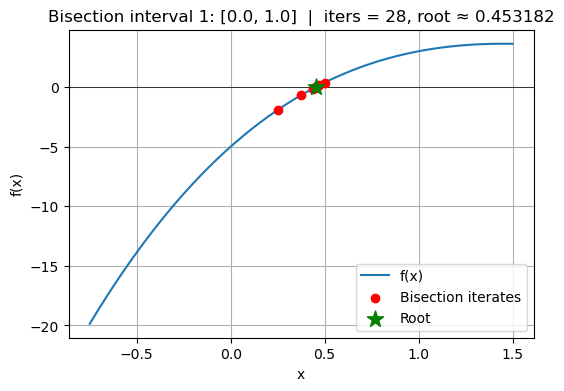


Running bisection on interval 2: [0.0, 5.0]
[0.0, 5.0] Iter 1: c = 2.5, f(c) = 1.875, relative error = 0.0 (first step)
[0.0, 2.5] Iter 2: c = 1.25, f(c) = 3.515625, relative error = 1.0
[0.0, 1.25] Iter 3: c = 0.625, f(c) = 1.259765625, relative error = 1.0
[0.0, 0.625] Iter 4: c = 0.3125, f(c) = -1.278076171875, relative error = 1.0
[0.3125, 0.625] Iter 5: c = 0.46875, f(c) = 0.127410888671875, relative error = 0.3333333333333333
[0.3125, 0.46875] Iter 6: c = 0.390625, f(c) = -0.5397605895996094, relative error = 0.2
[0.390625, 0.46875] Iter 7: c = 0.4296875, f(c) = -0.19746065139770508, relative error = 0.09090909090909091
[0.4296875, 0.46875] Iter 8: c = 0.44921875, f(c) = -0.03286868333816528, relative error = 0.043478260869565216
[0.44921875, 0.46875] Iter 9: c = 0.458984375, f(c) = 0.04780735820531845, relative error = 0.02127659574468085
[0.44921875, 0.458984375] Iter 10: c = 0.4541015625, f(c) = 0.007603750564157963, relative error = 0.010752688172043012
[0.44921875, 0.454101

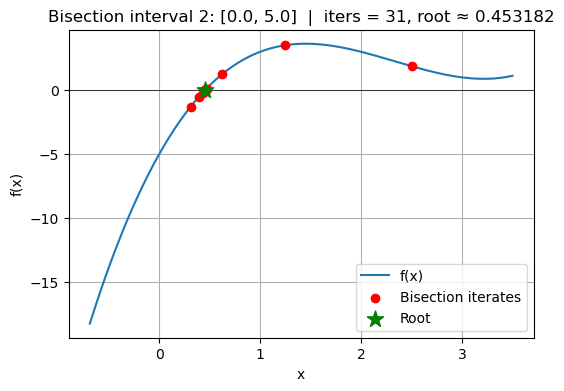


Running bisection on interval 3: [0.0, 10.0]
[0.0, 10.0] Iter 1: c = 5.0, f(c) = 15.0, relative error = 0.0 (first step)
[0.0, 5.0] Iter 2: c = 2.5, f(c) = 1.875, relative error = 1.0
[0.0, 2.5] Iter 3: c = 1.25, f(c) = 3.515625, relative error = 1.0
[0.0, 1.25] Iter 4: c = 0.625, f(c) = 1.259765625, relative error = 1.0
[0.0, 0.625] Iter 5: c = 0.3125, f(c) = -1.278076171875, relative error = 1.0
[0.3125, 0.625] Iter 6: c = 0.46875, f(c) = 0.127410888671875, relative error = 0.3333333333333333
[0.3125, 0.46875] Iter 7: c = 0.390625, f(c) = -0.5397605895996094, relative error = 0.2
[0.390625, 0.46875] Iter 8: c = 0.4296875, f(c) = -0.19746065139770508, relative error = 0.09090909090909091
[0.4296875, 0.46875] Iter 9: c = 0.44921875, f(c) = -0.03286868333816528, relative error = 0.043478260869565216
[0.44921875, 0.46875] Iter 10: c = 0.458984375, f(c) = 0.04780735820531845, relative error = 0.02127659574468085
[0.44921875, 0.458984375] Iter 11: c = 0.4541015625, f(c) = 0.00760375056415

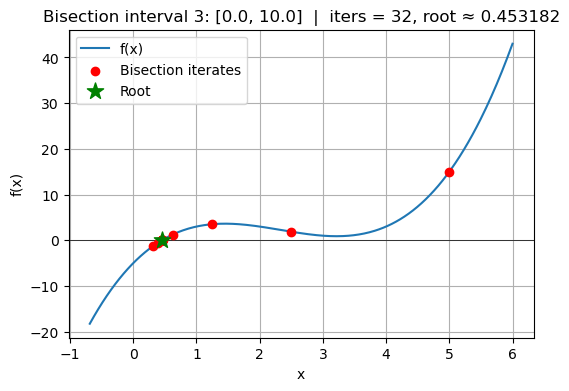

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import os

# symbolic definition of f
x_sym = sp.symbols('x')
f_sym = x_sym**3 - 7*x_sym**2 + 14*x_sym - 5
f = sp.lambdify(x_sym, f_sym, 'numpy')   # numeric version
def bisection_single(a, b, max_iter=50, precision=1e-8):
    if f(a) * f(b) > 0:
        print(f"Error for interval [{a}, {b}]: f(a) and f(b) must have opposite signs.")
        return None

    cs = []               # midpoints
    fcs = []              # f(c) values
    c_old = None

    for k in range(max_iter):
        c = (a + b) / 2.0
        fc = f(c)

        cs.append(c)
        fcs.append(fc)

        # relative error: |c - c_old| / |c|
        if c_old is None:
            rel_err = 0.0
            print(f"[{a}, {b}] Iter {k+1}: c = {c}, f(c) = {fc}, relative error = {rel_err} (first step)")
        else:
            rel_err = abs(c - c_old) / max(abs(c), 1e-16)
            print(f"[{a}, {b}] Iter {k+1}: c = {c}, f(c) = {fc}, relative error = {rel_err}")

        # stop if converged
        if c_old is not None and rel_err < precision:
            print(f"Root approximation for interval [{a}, {b}]: {c} after {k+1} iterations")
            num_iters = k + 1
            root_approx = c
            break

        # usual bisection update
        if f(a) * fc < 0:
            b = c
        else:
            a = c

        c_old = c

    else:
        # if loop didn't break (no convergence within max_iter)
        num_iters = max_iter
        root_approx = cs[-1]

    # return iteration history plus number of iterations and root approximation
    return cs, fcs, a, b, num_iters, root_approx

def bisection_three():
    max_iter = int(input("Enter max number of iterations: "))

    intervals = []
    for i in range(3):
        print(f"\n=== Interval {i+1} ===")
        a = float(input("Enter left endpoint a: "))
        b = float(input("Enter right endpoint b: "))
        intervals.append((a, b))

    # save to current working directory (where your notebook runs)
    save_dir = os.getcwd()
    print(f"Plots will be saved to: {save_dir}")

    for i, (a, b) in enumerate(intervals, start=1):
        print(f"\nRunning bisection on interval {i}: [{a}, {b}]")
        result = bisection_single(a, b, max_iter=max_iter, precision=1e-8)
        if result is None:
            continue  # skip invalid interval

        cs, fcs, a_last, b_last, num_iters, root_approx = result

        # plotting for this interval
        x_min = min(a_last, b_last, *cs) - 1
        x_max = max(a_last, b_last, *cs) + 1
        x_plot = np.linspace(x_min, x_max, 400)
        y_plot = f(x_plot)

        plt.figure(figsize=(6, 4))
        plt.axhline(0, color='black', linewidth=0.5)
        plt.plot(x_plot, y_plot, label='f(x)')
        # all iterates in red circles
        plt.scatter(cs, fcs, color='red', zorder=3, label='Bisection iterates')

        # mark the root with a different symbol (green star, bigger)
        plt.scatter(
            [root_approx],
            [f(root_approx)],
            color='green',
            marker='*',
            s=150,
            zorder=4,
            label='Root'
        )

        plt.xlabel('x')
        plt.ylabel('f(x)')
        plt.legend()
        plt.grid(True)

        # title with iterations and root value
        plt.title(
            f"Bisection interval {i}: [{a}, {b}]  |  "
            f"iters = {num_iters}, root ≈ {root_approx:.6f}"
        )

        # filename and save path
        filename = f"bisection_interval_{i}.png"
        save_path = os.path.join(save_dir, filename)

        plt.savefig(save_path, dpi=300)
        print(f"Saved plot for interval {i} as {save_path}")

        plt.show()

bisection_three()
